# Imports e Configuração

In [ ]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from neuralnet import NeuralNetwork
from layers import DenseLayer
from activation import SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam
from metrics import accuracy

from transformer_layers import SimpleTokenizer, TransformerClassifier

from utils import (
    train_test_split_stratified,
    accuracy_score_np,
    classification_report_np,
    confusion_matrix_np,
    prepare_label_arrays,
    build_vectorized_datasets,
    apply_human_confidence_rule,
    tune_human_threshold,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1. Carregamento e Preparação dos Dados

In [2]:
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

df_teste = pd.read_csv('../data/dataset-exemplos.csv', sep=';')
df_teste = df_teste.dropna(subset=['Text', 'Label'])

print("Distribuição do dataset de treino:")
print(df['Label'].value_counts())
print(f"\nTotal: {len(df)} amostras")

print("\nDistribuição do dataset de teste:")
print(df_teste['Label'].value_counts())
print(f"Total: {len(df_teste)} amostras")

Distribuição do dataset de treino:
Label
Human        999
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64

Total: 4995 amostras

Distribuição do dataset de teste:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64
Total: 125 amostras


In [3]:
X = df['Text'].values
y = df['Label'].values

X_teste = df_teste['Text'].values
y_teste = df_teste['Label'].values

X_train, X_val, y_train, y_val = train_test_split_stratified(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# Modelo de Regressão Logística de Baseline

Para estabelecer um ponto de referência, utilizamos o mesmo modelo de regressão logística do `numpy_models_2.ipynb`: vectorização TF-IDF com bigramas de palavras e uma camada densa com activação Softmax. Este baseline é deliberadamente simples — ignora a ordem das palavras e trata cada texto como um *saco de palavras* — o que nos permite medir o ganho real que a arquitectura Transformer traz.

In [4]:
label_data = prepare_label_arrays(y_train, y_val, y_teste)
labels      = label_data['labels']
class_to_idx = label_data['class_to_idx']
human_idx   = label_data['human_idx']
y_train_oh  = label_data['y_train_oh']
y_val_oh    = label_data['y_val_oh']
y_teste_oh  = label_data['y_test_oh']

baseline_data = build_vectorized_datasets(
    X_train,
    X_val,
    X_teste,
    y_train_oh,
    y_val_oh,
    y_teste_oh,
    vectorizer_params={
        'max_features': 3000,
        'ngram_range': (1, 2),
        'stop_words': 'english',
    },
)

vectorizer    = baseline_data['vectorizer']
X_train_vec   = baseline_data['X_train_vec']
X_val_vec     = baseline_data['X_val_vec']
X_teste_vec   = baseline_data['X_test_vec']
train_ds      = baseline_data['train_ds']
val_ds        = baseline_data['val_ds']
test_ds       = baseline_data['test_ds']

baseline = NeuralNetwork(
    epochs=200,
    batch_size=64,
    optimizer=Adam(learning_rate=0.01),
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=accuracy,
    patience=15,
)
baseline.add(DenseLayer(n_units=len(labels), input_shape=(X_train_vec.shape[1],), init_type='xavier'))
baseline.add(SoftmaxActivation())

baseline.fit(train_ds, val_dataset=val_ds, patience=15)

val_probs_base  = baseline.predict(val_ds)
test_probs_base = baseline.predict(test_ds)

raw_val_preds_base  = np.array([labels[i] for i in np.argmax(val_probs_base,  axis=1)])
raw_test_preds_base = np.array([labels[i] for i in np.argmax(test_probs_base, axis=1)])

base_best_threshold, base_best_bal_acc, base_best_acc = tune_human_threshold(
    val_probs_base, y_val, labels, human_idx,
)

val_preds_base  = apply_human_confidence_rule(val_probs_base,  labels, human_idx, base_best_threshold)
test_preds_base = apply_human_confidence_rule(test_probs_base, labels, human_idx, base_best_threshold)

base_val_acc_raw  = accuracy_score_np(y_val,   raw_val_preds_base)
base_val_acc_adj  = accuracy_score_np(y_val,   val_preds_base)
base_test_acc_raw = accuracy_score_np(y_teste, raw_test_preds_base)
base_test_acc_adj = accuracy_score_np(y_teste, test_preds_base)

Epoch 1/200 - loss: 1.3681 - val_loss: 1.1669 - accuracy: 0.5840
Epoch 10/200 - loss: 0.2565 - val_loss: 0.5051 - accuracy: 0.9850
Epoch 20/200 - loss: 0.1103 - val_loss: 0.4261 - accuracy: 0.9997
Epoch 30/200 - loss: 0.0604 - val_loss: 0.4102 - accuracy: 1.0000
Epoch 40/200 - loss: 0.0371 - val_loss: 0.4094 - accuracy: 1.0000
Epoch 50/200 - loss: 0.0244 - val_loss: 0.4150 - accuracy: 1.0000

[Early Stopping] Parou na época 51. Melhor Val Loss: 0.4085


## Análise de Métricas e Resultados

Best Human confidence threshold (val): 0.40
Validation balanced accuracy (adjusted): 0.8470
Validation accuracy  raw → adjusted: 0.8470 → 0.8470
Test accuracy        raw → adjusted: 0.5680 → 0.5680

Classification report (teste) - Baseline adjusted:
class          precision    recall  f1-score   support
Anthropic         0.6667    0.0870    0.1538        23
Google            0.4375    0.4375    0.4375        16
Human             0.6528    0.9038    0.7581        52
Meta              0.5000    0.6471    0.5641        17
OpenAI            0.3333    0.2353    0.2759        17

macro avg         0.5181    0.4621    0.4379       125
weighted avg      0.5636    0.5680    0.5139       125


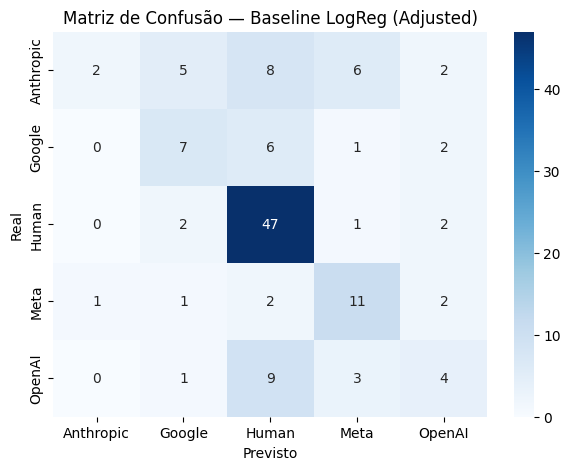

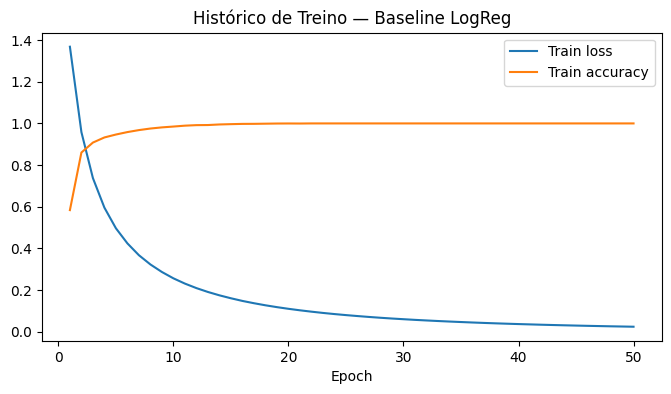

In [5]:
print(f'Best Human confidence threshold (val): {base_best_threshold:.2f}')
print(f'Validation balanced accuracy (adjusted): {base_best_bal_acc:.4f}')
print(f'Validation accuracy  raw → adjusted: {base_val_acc_raw:.4f} → {base_val_acc_adj:.4f}')
print(f'Test accuracy        raw → adjusted: {base_test_acc_raw:.4f} → {base_test_acc_adj:.4f}')
print('\nClassification report (teste) - Baseline adjusted:')
print(classification_report_np(y_teste, test_preds_base, labels))

cm_base    = confusion_matrix_np(y_teste, test_preds_base, labels)
cm_base_df = pd.DataFrame(cm_base, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_base_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão — Baseline LogReg (Adjusted)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

history_base_df = pd.DataFrame.from_dict(baseline.history, orient='index')
plt.figure(figsize=(8, 4))
plt.plot(history_base_df.index, history_base_df['loss'],   label='Train loss')
plt.plot(history_base_df.index, history_base_df['metric'], label='Train accuracy')
plt.title('Histórico de Treino — Baseline LogReg')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Modelo Transformer — Arquitectura e Motivação

## Por que Transformers para classificação de texto?

Os modelos de *bag-of-words* (como TF-IDF + regressão logística) tratam cada texto como um conjunto não ordenado de palavras. Perdem informação sobre:

- a **posição** das palavras na frase;
- o **contexto** em que cada palavra aparece;
- **dependências de longa distância** entre tokens.

O **Transformer Encoder**, introduzido por Vaswani *et al.* (2017), resolve isto através do mecanismo de **atenção multi-cabeça** (*multi-head self-attention*): para cada token, o modelo aprende quais os outros tokens da sequência que são mais relevantes e pondera a sua representação em função disso. O processo é **paralelo** (ao contrário de RNNs/LSTMs) e captura dependências independentemente da distância.

---

## Arquitectura implementada

```
texto → Tokenização → Embedding + Pos. Encoding
      → [TransformerBlock × n_blocks]
      → Global Average Pooling
      → Dense → Softmax → classe
```

### 1 · Embedding de palavras
Cada token do vocabulário é mapeado para um vector denso de dimensão `d_model = 64`. Os pesos desta tabela são **aprendidos** durante o treino via retropropagação (`np.add.at` para acumular gradientes nos índices visitados).

### 2 · Codificação posicional (sinusoidal, fixa)
Como a atenção é invariante à ordem, adicionamos um sinal posicional fixo a cada posição $p$:

$$\text{PE}(p, 2i)   = \sin\!\left(\frac{p}{10000^{2i/d_{\text{model}}}}\right), \qquad
  \text{PE}(p, 2i+1) = \cos\!\left(\frac{p}{10000^{2i/d_{\text{model}}}}\right)$$

Sendo um sinal fixo, o gradiente passa por ele sem alterações.

### 3 · Bloco Transformer (post-LN)
Cada bloco repete duas sub-camadas:

**Sub-camada 1 — Multi-Head Self-Attention:**

$$Q = X W_Q,\quad K = X W_K,\quad V = X W_V$$

$$\text{head}_h = \text{softmax}\!\left(\frac{Q_h K_h^\top}{\sqrt{d_k}}\right) V_h, \qquad d_k = d_{\text{model}} / n\_heads$$

$$\text{MHA}(X) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)\, W_O$$

**Sub-camada 2 — Feed-Forward position-wise (FFN):**

$$\text{FFN}(x) = \text{ReLU}(x W_1 + b_1)\, W_2 + b_2$$

Cada sub-camada inclui **ligação residual** e **Layer Normalization** (post-LN):

$$x_1 = \text{LN}(x + \text{Dropout}(\text{MHA}(x)))$$
$$x_2 = \text{LN}(x_1 + \text{Dropout}(\text{FFN}(x_1)))$$

### 4 · Global Average Pooling
Após os blocos Transformer, agregamos as representações de todos os tokens com média aritmética, obtendo um único vector de dimensão `d_model` por exemplo.

### 5 · Cabeça de classificação
Uma camada densa seguida de Softmax mapeia o vector agregado para probabilidades sobre as 5 classes.

---

## Implementação em NumPy puro

Todo o modelo está implementado em `models/numpy_models/transformer_layers.py` usando **exclusivamente NumPy**:

| Componente | Gradiente manual |
|---|---|
| Softmax + Cross-Entropy | $\nabla = (\hat{y} - y) / N$ |
| Multi-Head Attention | Regra da cadeia sobre $\text{softmax}(QK^\top/\sqrt{d_k})\cdot V$ |
| Layer Norm | Gradiente analítico da normalização |
| Embedding look-up | `np.add.at` para acumulação esparsa |
| Ligação residual | Soma dos gradientes dos dois caminhos |

Os pesos são actualizados com **Adam** (instâncias independentes por tensor, via `copy.deepcopy`).

# Preparação dos Dados para o Transformer

Ao contrário da regressão logística que recebe vectores TF-IDF densos, o Transformer recebe **sequências de índices de tokens**. O processo é:

1. **Tokenização**: cada texto é fragmentado em palavras (expressão regular `[A-Za-z0-9']+`).
2. **Construção do vocabulário**: as `max_vocab` palavras mais frequentes no treino formam o vocabulário; palavras desconhecidas no teste são mapeadas para `<UNK>`.
3. **Padding/Truncagem**: cada sequência é padded ou truncada para `max_seq_len` tokens.

O tokenizador é ajustado **apenas nos dados de treino** para evitar *data leakage*.

In [6]:
MAX_VOCAB   = 5000
MAX_SEQ_LEN = 100

tokenizer = SimpleTokenizer(max_vocab=MAX_VOCAB, max_seq_len=MAX_SEQ_LEN)
X_train_tok = tokenizer.fit_transform(X_train)
X_val_tok   = tokenizer.transform(X_val)
X_teste_tok = tokenizer.transform(X_teste)

vocab_size = tokenizer.vocab_size
print(f'Vocabulário: {vocab_size} tokens')
print(f'Sequências de treino:  {X_train_tok.shape}')
print(f'Sequências de val:     {X_val_tok.shape}')
print(f'Sequências de teste:   {X_teste_tok.shape}')

# Reutiliza os arrays one-hot gerados na secção do baseline
# (mesmas classes, mesma ordem → human_idx mantém-se válido)
n_classes = label_data['n_classes']
print(f'\nClasses ({n_classes}):', labels)

Vocabulário: 5000 tokens
Sequências de treino:  (3995, 100)
Sequências de val:     (1000, 100)
Sequências de teste:   (125, 100)

Classes (5): ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


# Treino do Transformer

## Configuração de hiperparâmetros

| Hiperparâmetro | Valor | Justificação |
|---|---|---|
| `embed_dim` | 64 | Suficiente para capturar semântica sem explodir a memória em NumPy puro |
| `n_heads` | 4 | 4 cabeças com $d_k = 16$ — equilíbrio entre expressividade e custo |
| `d_ff` | 128 | Camada FFN 2× maior que `d_model`, regra de escala standard |
| `n_blocks` | 2 | Dois blocos empilhados permitem composição de features de ordem superior |
| `max_seq_len` | 100 | Cobre a maioria dos textos do dataset sem custo quadrático excessivo |
| `dropout_rate` | 0.1 | Regularização leve; o dataset é pequeno |
| `learning_rate` | 0.001 | Valor padrão do Adam para Transformers |
| `batch_size` | 32 | Mini-batches pequenos para melhor generalização |
| `patience` | 10 | Early stopping conservador |

> **Nota sobre tempo de execução:** a atenção tem complexidade $O(L^2 \cdot d_{\text{model}})$ por batch.  
> Num dataset pequeno com NumPy puro, cada época demora tipicamente poucos segundos.

In [7]:
transformer = TransformerClassifier(
    vocab_size   = vocab_size,
    n_classes    = n_classes,
    embed_dim    = 64,
    n_heads      = 4,
    d_ff         = 128,
    n_blocks     = 2,
    max_seq_len  = MAX_SEQ_LEN,
    dropout_rate = 0.1,
    epochs       = 60,
    batch_size   = 32,
    optimizer    = Adam(learning_rate=0.001),
    patience     = 10,
    verbose      = 5,
)

transformer.fit(
    X_train_tok, y_train_oh,
    X_val     = X_val_tok,
    y_val_oh  = y_val_oh,
)

val_probs_tr   = transformer.predict(X_val_tok)
test_probs_tr  = transformer.predict(X_teste_tok)

raw_val_preds_tr  = np.array([labels[i] for i in np.argmax(val_probs_tr,  axis=1)])
raw_test_preds_tr = np.array([labels[i] for i in np.argmax(test_probs_tr, axis=1)])

Epoch    5 | loss: 0.1588 | acc: 0.9414 | val_loss: 0.7071
Epoch   10 | loss: 0.0417 | acc: 0.9867 | val_loss: 1.1542
  Early stopping at epoch 13


## Análise de Métricas e Resultados

Best Human confidence threshold (val): 0.85
Validation balanced accuracy (adjusted): 0.8010
Validation accuracy  raw → adjusted: 0.7740 → 0.8010
Test accuracy        raw → adjusted: 0.5360 → 0.6000

Classification report (teste) — Transformer adjusted:
class          precision    recall  f1-score   support
Anthropic         0.5714    0.3478    0.4324        23
Google            0.4762    0.6250    0.5405        16
Human             0.7143    0.7692    0.7407        52
Meta              0.6154    0.4706    0.5333        17
OpenAI            0.4286    0.5294    0.4737        17

macro avg         0.5612    0.5484    0.5441       125
weighted avg      0.6052    0.6000    0.5939       125


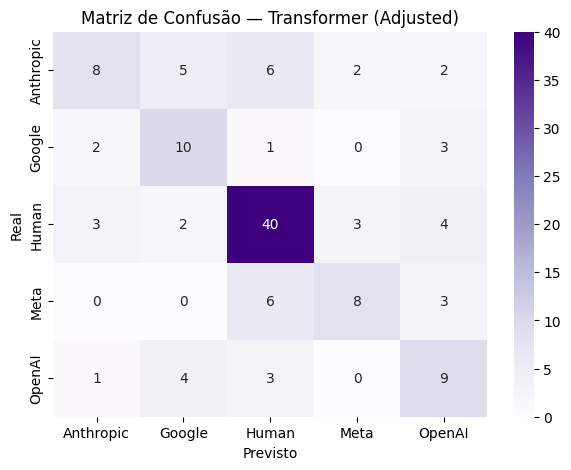

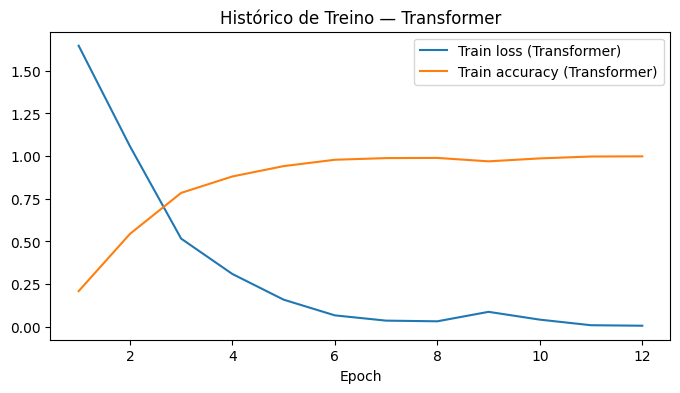

In [8]:
tr_best_threshold, tr_best_bal_acc, tr_best_acc = tune_human_threshold(
    val_probs_tr, y_val, labels, human_idx,
)

val_preds_tr  = apply_human_confidence_rule(val_probs_tr,  labels, human_idx, tr_best_threshold)
test_preds_tr = apply_human_confidence_rule(test_probs_tr, labels, human_idx, tr_best_threshold)

tr_val_acc_raw  = accuracy_score_np(y_val,   raw_val_preds_tr)
tr_val_acc_adj  = accuracy_score_np(y_val,   val_preds_tr)
tr_test_acc_raw = accuracy_score_np(y_teste, raw_test_preds_tr)
tr_test_acc_adj = accuracy_score_np(y_teste, test_preds_tr)

print(f'Best Human confidence threshold (val): {tr_best_threshold:.2f}')
print(f'Validation balanced accuracy (adjusted): {tr_best_bal_acc:.4f}')
print(f'Validation accuracy  raw → adjusted: {tr_val_acc_raw:.4f} → {tr_val_acc_adj:.4f}')
print(f'Test accuracy        raw → adjusted: {tr_test_acc_raw:.4f} → {tr_test_acc_adj:.4f}')
print('\nClassification report (teste) — Transformer adjusted:')
print(classification_report_np(y_teste, test_preds_tr, labels))

cm_tr    = confusion_matrix_np(y_teste, test_preds_tr, labels)
cm_tr_df = pd.DataFrame(cm_tr, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_tr_df, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusão — Transformer (Adjusted)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

history_tr_df = pd.DataFrame.from_dict(transformer.history, orient='index')
plt.figure(figsize=(8, 4))
plt.plot(history_tr_df.index, history_tr_df['loss'], label='Train loss (Transformer)')
plt.plot(history_tr_df.index, history_tr_df['acc'],  label='Train accuracy (Transformer)')
plt.title('Histórico de Treino — Transformer')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Comparação Final: Baseline vs Transformer (Raw vs Adjusted)

A coluna **"Raw"** reflecte as predições directas do modelo (argmax das probabilidades).  
A coluna **"Adjusted"** aplica a regra de confiança mínima para a classe *Human*: se a probabilidade de *Human* for inferior ao threshold óptimo encontrado na validação, o segundo argmax é usado em vez disso.  
A **"Val Balanced Accuracy"** é a média dos recalls por classe e é mais robusta em presença de desequilíbrio de classes.

Resumo comparativo:


,Model,Val Accuracy (Raw),Val Accuracy (Adjusted),Test Accuracy (Raw),Test Accuracy (Adjusted),Best Human Threshold,Val Balanced Accuracy (Adjusted)
0,Baseline LogReg,0.847,0.847,0.568,0.568,0.40,0.847
1,Transformer,0.774,0.801,0.536,0.600,0.85,0.801


<Figure size 800x400 with 0 Axes>

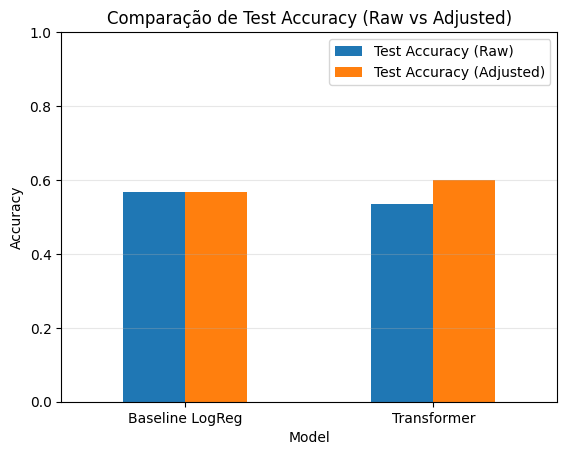

In [9]:
comparison_df = pd.DataFrame(
    [
        {
            'Model': 'Baseline LogReg',
            'Val Accuracy (Raw)':              base_val_acc_raw,
            'Val Accuracy (Adjusted)':         base_val_acc_adj,
            'Test Accuracy (Raw)':             base_test_acc_raw,
            'Test Accuracy (Adjusted)':        base_test_acc_adj,
            'Best Human Threshold':            base_best_threshold,
            'Val Balanced Accuracy (Adjusted)': base_best_bal_acc,
        },
        {
            'Model': 'Transformer',
            'Val Accuracy (Raw)':              tr_val_acc_raw,
            'Val Accuracy (Adjusted)':         tr_val_acc_adj,
            'Test Accuracy (Raw)':             tr_test_acc_raw,
            'Test Accuracy (Adjusted)':        tr_test_acc_adj,
            'Best Human Threshold':            tr_best_threshold,
            'Val Balanced Accuracy (Adjusted)': tr_best_bal_acc,
        },
    ]
)

numeric_cols = [
    'Val Accuracy (Raw)',
    'Val Accuracy (Adjusted)',
    'Test Accuracy (Raw)',
    'Test Accuracy (Adjusted)',
    'Best Human Threshold',
    'Val Balanced Accuracy (Adjusted)',
]
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

print('Resumo comparativo:')
display(comparison_df)

plt.figure(figsize=(8, 4))
plot_df = comparison_df.set_index('Model')[['Test Accuracy (Raw)', 'Test Accuracy (Adjusted)']]
plot_df.plot(kind='bar', rot=0)
plt.title('Comparação de Test Accuracy (Raw vs Adjusted)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()